# Caso 1 - Clasificación Iris con Keras (Python)

Equivalente Python del caso R con `neuralnet`: mismo dataset (150 datos, 4 variables predictoras, 3 clases), mismo split 70/30, arquitectura equivalente (2 capas ocultas de 10 neuronas).

<style>
.conceptbox, .taskbox, .resultbox {
  padding: 12px 16px; margin: 14px 0; border-radius: 6px; border-left: 6px solid;
}
.conceptbox { background:#20B2AA0D; border-color:#20B2AA; }
.taskbox    { background:#FF8C000D; border-color:#FF8C00; }
.resultbox  { background:#32CD320D; border-color:#32CD32; }
.conceptbox b.tag { color:#178077; }
.taskbox b.tag    { color:#B35F00; }
.resultbox b.tag   { color:#228B22; }
</style>

<div class="taskbox">
<b class="tag">Objetivo de este notebook</b><br>
Entrenar y evaluar, en Python/Keras, la misma arquitectura de red usada en R con <code>neuralnet</code>
(<a href="iris_neuralnet.Rmd">iris_neuralnet.Rmd</a>), para comparar directamente ambas
implementaciones sobre el mismo problema de clasificación de 3 especies de Iris.
</div>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(123)
tf.random.set_seed(123)

## Datos

<div class="conceptbox">
<b class="tag">¿Por qué este split y por qué one-hot?</b><br>
Igual que en la versión R: se separa 70% para entrenar y 30% para validar, de forma que la
tasa de error final se mida sobre observaciones que la red <em>nunca vio</em> durante el ajuste
de pesos (si evaluáramos sobre los datos de entrenamiento, un modelo suficientemente flexible
podría memorizarlos y la métrica no reflejaría su capacidad real de generalizar).
<br><br>
<code>keras.utils.to_categorical</code> convierte la etiqueta de clase (0, 1 o 2) en un vector
one-hot de 3 posiciones (por ejemplo, clase 1 → <code>[0, 1, 0]</code>), que es el formato que
espera la función de pérdida <code>categorical_crossentropy</code> junto con una capa de salida
<code>softmax</code>.
</div>

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.30, random_state=123, stratify=None
)

y_train_oh = keras.utils.to_categorical(y_train, num_classes=3)
y_valid_oh = keras.utils.to_categorical(y_valid, num_classes=3)

X_train.shape, X_valid.shape

((105, 4), (45, 4))

## Arquitectura de la red

4 entradas -> Dense(10, relu) -> Dense(10, relu) -> Dense(3, softmax). Equivalente a `hidden=c(10,10)` del caso en R.

<div class="conceptbox">
<b class="tag">Cada pieza de la arquitectura, explicada</b><br>
<ul>
<li><b>Dense(10, relu) x2:</b> mismas 2 capas ocultas de 10 neuronas que en R
(<code>hidden=c(10,10)</code>). Cada neurona calcula una combinación lineal de sus entradas más un
sesgo, y aplica la función de activación <code>relu</code> (<i>Rectified Linear Unit</i>,
<code>max(0,x)</code>), que en Keras es la elección por defecto para capas ocultas por ser simple
de calcular y evitar el problema de "gradientes que se desvanecen" en redes profundas.</li>
<li><b>Dense(3, softmax):</b> la capa de salida tiene una neurona por especie; <code>softmax</code>
convierte los 3 valores crudos en probabilidades que suman 1, de forma que cada salida se
interpreta directamente como "probabilidad estimada de esa especie". Esto es el equivalente
Keras de <code>linear.output=FALSE</code> en <code>neuralnet</code>.</li>
<li><b>categorical_crossentropy:</b> función de pérdida estándar para clasificación multiclase,
análoga al <code>err.fct="ce"</code> (entropía cruzada) usado en el caso R.</li>
<li><b>adam:</b> algoritmo de optimización que ajusta automáticamente la tasa de aprendizaje de
cada peso durante el entrenamiento; es la alternativa moderna al descenso de gradiente clásico
que usa internamente <code>neuralnet</code>, y suele converger más rápido en la práctica.</li>
</ul>
</div>

In [3]:
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(10, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(3, activation="softmax"),
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_valid, y_valid_oh),
    epochs=200,
    verbose=0,
)
print("Última acc entrenamiento:", history.history["accuracy"][-1])
print("Última acc validación:", history.history["val_accuracy"][-1])

Última acc entrenamiento: 0.9809523820877075
Última acc validación: 0.9555555582046509


## Predicción y evaluación

<div class="conceptbox">
<b class="tag">De probabilidades a una clase concreta</b><br>
<code>model.predict</code> devuelve, para cada observación de validación, las 3 probabilidades de
salida (softmax). <code>np.argmax</code> por fila elige el índice de la probabilidad más alta,
que se traduce de vuelta al nombre de la especie mediante <code>class_names</code>. Es exactamente
el mismo procedimiento que <code>which.max</code> aplicado al resultado de <code>compute()</code>
en la versión R.
</div>

In [5]:
probs = model.predict(X_valid, verbose=0)
y_pred = np.argmax(probs, axis=1)
predicted = class_names[y_pred]
actual = class_names[y_valid]

cm = confusion_matrix(actual, predicted, labels=class_names)
pd.DataFrame(cm, index=class_names, columns=class_names)

,setosa,versicolor,virginica
setosa,18,0,0
versicolor,0,9,1
virginica,0,1,16


In [6]:
te = 1 - accuracy_score(actual, predicted)
print(f"Tasa de error: {te:.4f}")
print(f"Accuracy: {1 - te:.4f}")

Tasa de error: 0.0444
Accuracy: 0.9556


## Curvas de entrenamiento

<div class="conceptbox">
<b class="tag">Para qué sirven estas curvas</b><br>
Graficar accuracy/loss de entrenamiento junto con las de validación por época permite detectar
<b>sobreajuste</b>: si la curva de entrenamiento sigue mejorando mientras la de validación se
estanca o empeora, la red está memorizando particularidades de los datos de entrenamiento en vez
de aprender patrones que generalicen. En un dataset tan pequeño y simple como Iris, ambas curvas
suelen converger juntas sin mostrar ese problema.
</div>

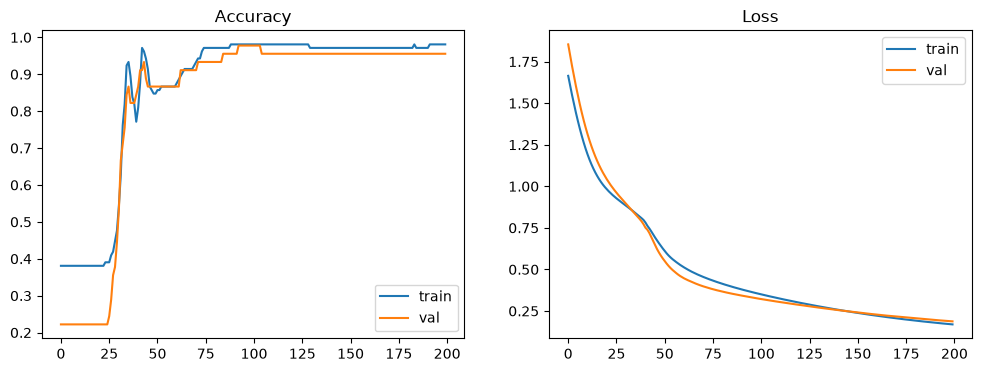

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()
plt.show()

## Guardar modelo para la app

<div class="resultbox">
<b class="tag">Resultado clave</b><br>
El modelo entrenado se guarda en formato <code>.keras</code> para ser reutilizado directamente por
las apps interactivas (<code>app_streamlit.py</code> y <code>app_dash.py</code>) sin necesidad de
reentrenar. La tasa de error y matriz de confusión calculadas arriba son directamente comparables
con las obtenidas en R (<a href="iris_neuralnet.Rmd"><code>iris_neuralnet.Rmd</code></a>), ya que
ambas usan la misma arquitectura, el mismo split y la misma semilla aleatoria.
</div>

In [8]:
import os
os.makedirs("../app/models", exist_ok=True)
model.save("../app/models/iris_model.keras")
print("Modelo guardado en app/models/iris_model.keras")

Modelo guardado en app/models/iris_model.keras
